In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [2]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# Calculate potential vorticity
df_ST = calc_pv(df_ST)

In [3]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Define a list of random seeds
seeds = random.sample(range(1, 10000), 5)

In [4]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]','Pv']

In [5]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/TemporalAnalysis/funcs.py:933: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [6]:
# Cut dataset to only 2010-2023 for clustering
df_sampled = df_sampled[df_sampled['year'] > 2010]

In [7]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 11)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seeds[0]) # full cov matrix has more flexibility
    gmm.fit(df_sampled[features])
    bic_scores.append(gmm.bic(df_sampled[features]))

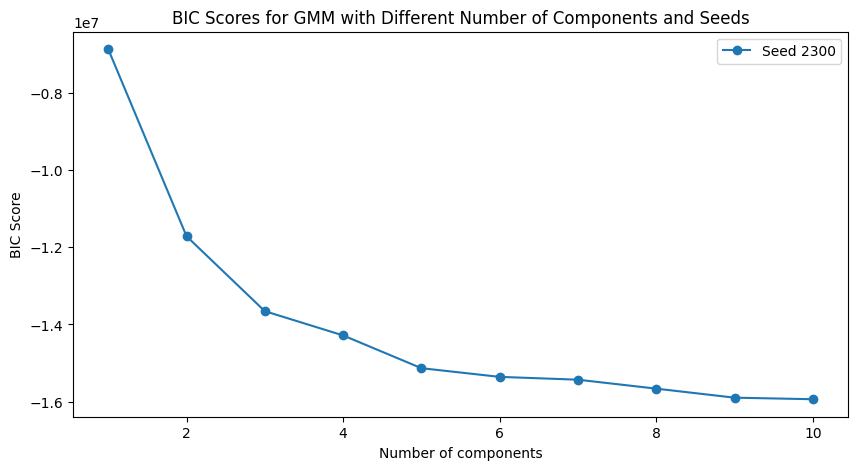

In [8]:
plt.figure(figsize=(10,5))
plt.plot(n_components_range, bic_scores, label=f'Seed {seeds[0]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
plt.legend()

In [9]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [10]:
gmm = GaussianMixture(
    n_components=n_clusters,          # number of clusters
    covariance_type='full',  # full cov matrix has more flexibility
    random_state=seeds[0])

labels = gmm.fit_predict(df_sampled[features])

In [11]:
df_sampled['gmm_label_6'] = labels

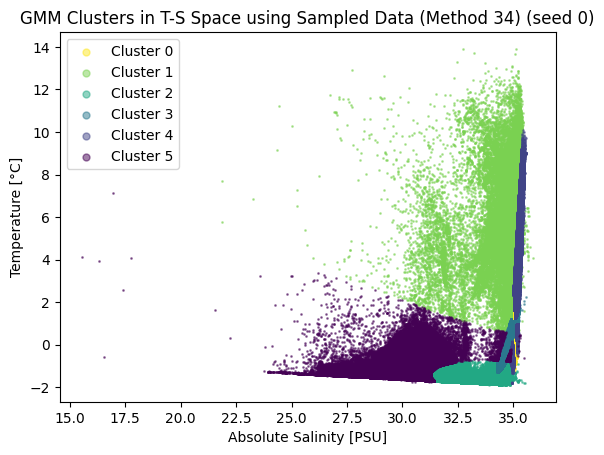

In [12]:
plt.figure()

# Discrete Viridis colours full range (reversed)
colors = plt.cm.viridis_r(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    mask = df_sampled['gmm_label_6'] == i
    plt.scatter(
        df_sampled.loc[mask, 'Absolute_Salinity_[PSU]'],
        df_sampled.loc[mask, 'Conservative_Temperature_[deg_C]'],
        s=1,
        alpha=0.5,
        color=colors[i],
        label=f'Cluster {i}')

plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [°C]")
plt.title("GMM Clusters in T-S Space using Sampled Data (Method 34) (seed 0)")
plt.legend(loc='upper left', markerscale=5)
plt.show()

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/TemporalAnalysis/funcs.py:603: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



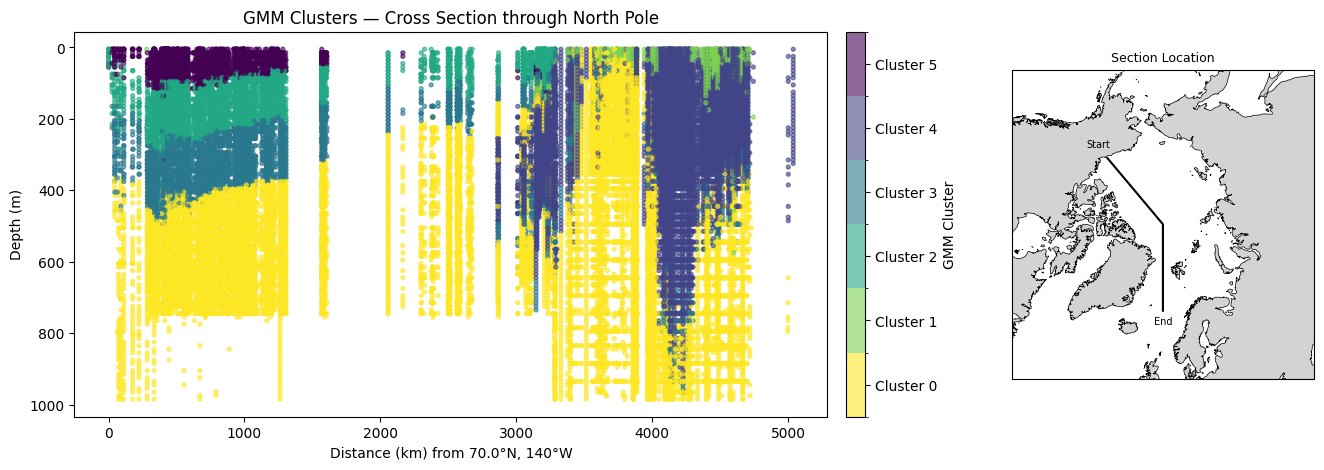

In [13]:
cross_sec_lon(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [14]:
for i in range(n_clusters):
    df_sampled['prob_cluster_'+str(i)] = gmm.predict_proba(df_sampled[features])[:, i]

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/TemporalAnalysis/funcs.py:836: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



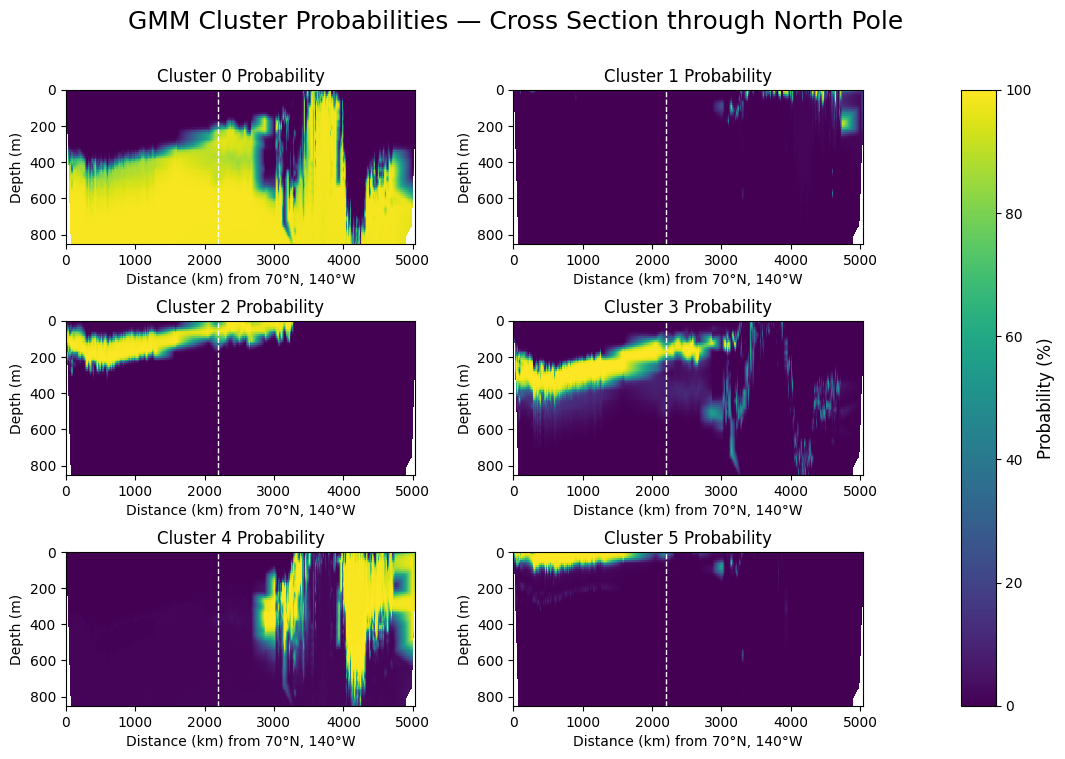

In [15]:
cross_sec_lon_prob2(df_sampled, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)

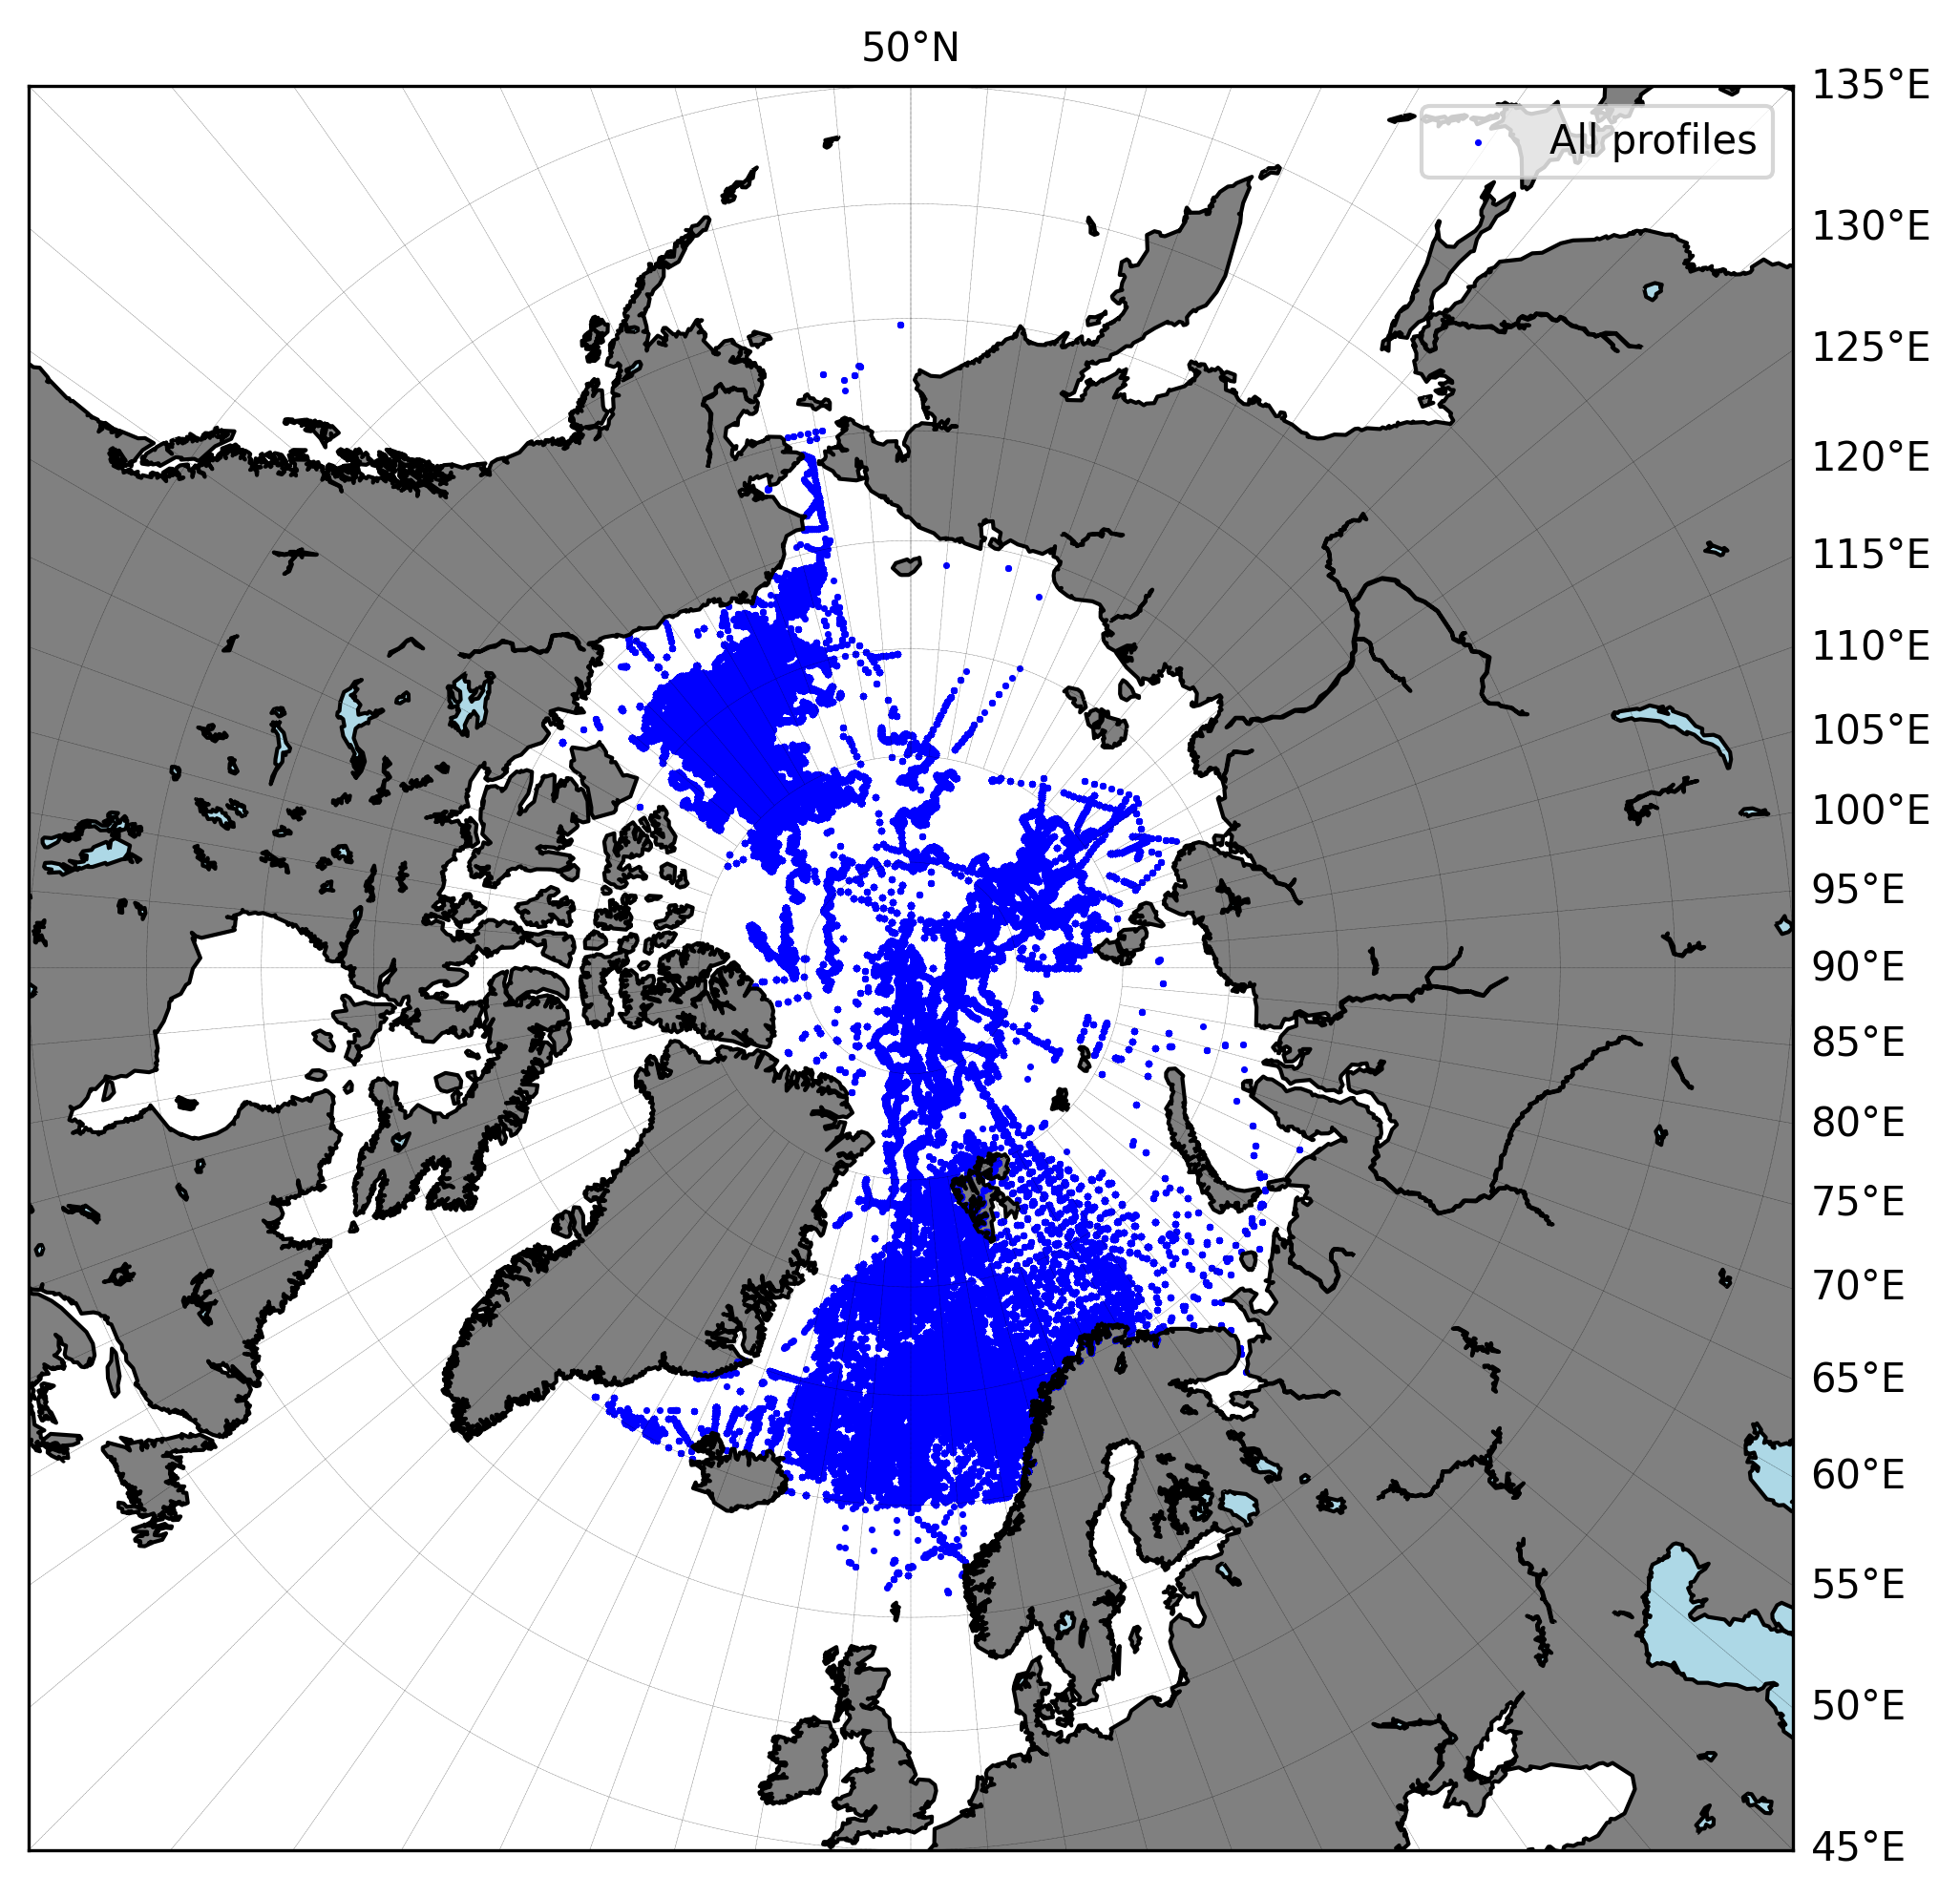

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

# Define the map bounds and resolution
lon_min, lon_max = -180, 180
lat_min, lat_max = 50, 90
latlon_step = 5
resolution = 'l'  # l for low resolution, h for high resolution

# Set up the figure and the Basemap instance
fig = plt.figure(figsize=(8,8),dpi=300)
m = Basemap(projection='npstere', boundinglat=lat_min, lon_0=0, resolution=resolution)

parallels = np.arange(lat_min, lat_max+1, 5)
meridians = np.arange(lon_min, lon_max+1, 5)

m.drawparallels(np.arange(lat_min, lat_max+1, latlon_step), labels=[False,False,True,False], linewidth=0.1)
m.drawmeridians(np.arange(lon_min, lon_max+1, latlon_step), labels=[False,True,False,False], linewidth=0.1)


m.drawcoastlines()
m.fillcontinents(color='grey',lake_color='lightblue')

# plot lat lon distribution of the data with pressure length larger than 1
x, y = m(df_sampled['Longitude_[deg_E]'].values, df_sampled['Latitude_[deg_N]'].values)
m.scatter(x, y, 0.5, marker='o', color='blue',label='All profiles')

# plot the legend on top right
plt.legend(loc='upper right')

# Show the plot
plt.show()